In [12]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [13]:
print("hi")

hi


In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve, auc
from tqdm import tqdm

# Install gdown to download from Drive link
!pip install -U gdown

# Download dataset
dataset_url = 'https://drive.google.com/uc?id=1znqUeFzYz-DeAE3dYXD17qoMPK82Whji'
!gdown {dataset_url} -O lensing_data.npy


Downloading...
From (original): https://drive.google.com/uc?id=1znqUeFzYz-DeAE3dYXD17qoMPK82Whji
From (redirected): https://drive.google.com/uc?id=1znqUeFzYz-DeAE3dYXD17qoMPK82Whji&confirm=t&uuid=607621d3-080f-46fe-b37d-bfcffdb00c56
To: /kaggle/working/lensing_data.npy
100%|███████████████████████████████████████| 2.89G/2.89G [00:25<00:00, 112MB/s]


In [ ]:
import zipfile
import os


if os.path.exists('lensing_data.npy'):
    os.rename('lensing_data.npy', 'lensing_data.zip')

with zipfile.ZipFile('lensing_data.zip', 'r') as zip_ref:
    zip_ref.extractall('lensing_extracted')

# Let's see where the images actually are
base_path = 'lensing_extracted/Dataset'
print("Extracted classes:", os.listdir(base_path))

Extracted classes: ['axion', 'cdm', 'no_sub']


In [ ]:
import torch
from torch.utils.data import Dataset
from PIL import Image
import glob

class LensingImageDataset(Dataset):
    def __init__(self, root_dir, mode='pretrain', transform=None):
        self.root_dir = root_dir
        self.mode = mode
        self.transform = transform
        
        self.classes = ['no_sub', 'cdm', 'axion']
        self.all_image_paths = []
        self.labels = []

        if mode == 'pretrain':
            # Only using 'no_sub' for MAE pre-training
            path = os.path.join(root_dir, 'no_sub', '*')
            self.all_image_paths = [p for p in glob.glob(path) if os.path.isfile(p)]
        else:
            # Using everything for classification
            for i, cls_name in enumerate(self.classes):
                path = os.path.join(root_dir, cls_name, '*')
                class_files = [p for p in glob.glob(path) if os.path.isfile(p)]
                self.all_image_paths.extend(class_files)
                self.labels.extend([i] * len(class_files))

    def __len__(self):
        return len(self.all_image_paths)

    def __getitem__(self, idx):
        img_path = self.all_image_paths[idx]
        # 
        try:
            # Assuming these are .npy or .png files. 
            # If they are .npy files , np.load:
            if img_path.endswith('.npy'):
                img = np.load(img_path).astype(np.float32)
            else:
                img = Image.open(img_path).convert('L') # Converts to grayscale
                img = np.array(img).astype(np.float32)
        except Exception as e:
            # Returns a blank image if one fails to load
            img = np.zeros((64, 64), dtype=np.float32)

        # Standardizing to (1, H, W) and normalizing to [0, 1]
        if img.ndim == 2:
            img = np.expand_dims(img, axis=0)
        
        # Simple normalization if not already done
        if img.max() > 1.0:
            img = img / 255.0
            
        img_tensor = torch.from_numpy(img)
        
        if self.mode == 'pretrain':
            return img_tensor
        return img_tensor, self.labels[idx]

# Usage:
# 

Single image shape: torch.Size([1, 64, 64])
Total pre-training images: 29449


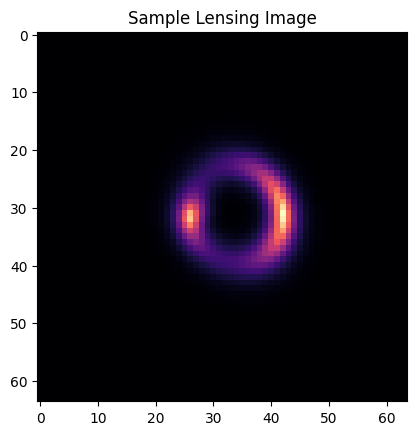

In [20]:
test_ds = LensingImageDataset(base_path, mode='pretrain')
sample_img = test_ds[0]
print(f"Single image shape: {sample_img.shape}") 
print(f"Total pre-training images: {len(test_ds)}")

plt.imshow(sample_img.squeeze(), cmap='magma')
plt.title("Sample Lensing Image")
plt.show()

In [23]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

def get_2d_sincos_pos_embed(embed_dim, grid_size, cls_token=False):
    grid_h = np.arange(grid_size, dtype=np.float32)
    grid_w = np.arange(grid_size, dtype=np.float32)
    grid = np.meshgrid(grid_w, grid_h)
    grid = np.stack(grid, axis=0)
    grid = grid.reshape([2, 1, grid_size, grid_size])
    pos_embed = get_2d_sincos_pos_embed_from_grid(embed_dim, grid)
    if cls_token:
        pos_embed = np.concatenate([np.zeros([1, embed_dim]), pos_embed], axis=0)
    return pos_embed

def get_2d_sincos_pos_embed_from_grid(embed_dim, grid):
    emb_h = get_1d_sincos_pos_embed_from_grid(embed_dim // 2, grid[0])
    emb_w = get_1d_sincos_pos_embed_from_grid(embed_dim // 2, grid[1])
    return np.concatenate([emb_h, emb_w], axis=1)

def get_1d_sincos_pos_embed_from_grid(embed_dim, pos):
    omega = np.arange(embed_dim // 2, dtype=np.float32)
    omega /= embed_dim / 2.
    omega = 1. / 10000**omega
    pos = pos.reshape(-1)
    out = np.einsum('m,d->md', pos, omega)
    return np.concatenate([np.sin(out), np.cos(out)], axis=1)

class MAE_ViT(nn.Module):
    def __init__(self, img_size=64, patch_size=4, in_chans=1,
                 embed_dim=128, depth=8, num_heads=4,
                 decoder_embed_dim=64, decoder_depth=2, decoder_num_heads=4):
        super().__init__()
        self.patch_size = patch_size
        self.patch_embed = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size, stride=patch_size)
        num_patches = (img_size // patch_size)**2
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches, embed_dim), requires_grad=False)
        self.blocks = nn.ModuleList([nn.TransformerEncoderLayer(embed_dim, num_heads, embed_dim*4, activation='gelu', batch_first=True) for _ in range(depth)])
        self.norm = nn.LayerNorm(embed_dim)
        self.decoder_embed = nn.Linear(embed_dim, decoder_embed_dim, bias=True)
        self.mask_token = nn.Parameter(torch.zeros(1, 1, decoder_embed_dim))
        self.decoder_pos_embed = nn.Parameter(torch.zeros(1, num_patches, decoder_embed_dim), requires_grad=False)
        self.decoder_blocks = nn.ModuleList([nn.TransformerEncoderLayer(decoder_embed_dim, decoder_num_heads, decoder_embed_dim*4, activation='gelu', batch_first=True) for _ in range(decoder_depth)])
        self.decoder_pred = nn.Linear(decoder_embed_dim, patch_size**2 * in_chans, bias=True)
        self.initialize_weights()

    def initialize_weights(self):
        pos_embed = get_2d_sincos_pos_embed(self.pos_embed.shape[-1], int(self.pos_embed.shape[1]**.5))
        self.pos_embed.data.copy_(torch.from_numpy(pos_embed).float().unsqueeze(0))
        decoder_pos_embed = get_2d_sincos_pos_embed(self.decoder_pos_embed.shape[-1], int(self.decoder_pos_embed.shape[1]**.5))
        self.decoder_pos_embed.data.copy_(torch.from_numpy(decoder_pos_embed).float().unsqueeze(0))

    def random_masking(self, x, mask_ratio):
        N, L, D = x.shape
        len_keep = int(L * (1 - mask_ratio))
        noise = torch.rand(N, L, device=x.device)
        ids_shuffle = torch.argsort(noise, dim=1)
        ids_restore = torch.argsort(ids_shuffle, dim=1)
        ids_keep = ids_shuffle[:, :len_keep]
        x_masked = torch.gather(x, dim=1, index=ids_keep.unsqueeze(-1).repeat(1, 1, D))
        mask = torch.ones([N, L], device=x.device)
        mask[:, :len_keep] = 0
        mask = torch.gather(mask, dim=1, index=ids_restore)
        return x_masked, mask, ids_restore

    def forward(self, imgs, mask_ratio=0.90):
        x = self.patch_embed(imgs).flatten(2).transpose(1, 2)
        x = x + self.pos_embed
        x, mask, ids_restore = self.random_masking(x, mask_ratio)
        for blk in self.blocks: x = blk(x)
        x = self.norm(x)
        x = self.decoder_embed(x)
        mask_tokens = self.mask_token.repeat(x.shape[0], ids_restore.shape[1] - x.shape[1], 1)
        x_ = torch.cat([x, mask_tokens], dim=1)
        x = torch.gather(x_, dim=1, index=ids_restore.unsqueeze(-1).repeat(1, 1, x.shape[2]))
        x = x + self.decoder_pos_embed
        for blk in self.decoder_blocks: x = blk(x)
        x = self.decoder_pred(x)
        return x, mask

def visualize_reconstruction(model, imgs, epoch):
    model.eval()
    with torch.no_grad():
        imgs_gpu = imgs[:1].to('cuda')
        pred, mask = model(imgs_gpu, mask_ratio=0.90)
        p = 4
        h = w = 16
        pred = pred.reshape(shape=(pred.shape[0], h, w, p, p, 1))
        pred = torch.einsum('nhwpqc->nchpwq', pred)
        reconstruction = pred.reshape(shape=(pred.shape[0], 1, 64, 64))
        plt.figure(figsize=(8, 4))
        plt.subplot(1, 2, 1); plt.imshow(imgs[0].squeeze().cpu(), cmap='magma'); plt.title("Original")
        plt.subplot(1, 2, 2); plt.imshow(reconstruction[0].squeeze().cpu(), cmap='magma'); plt.title(f"90% Reconstruction (Ep {epoch})")
        plt.show()

model = MAE_ViT().to('cuda')

Starting MAE Pre-training (90% Masking)...


100%|██████████| 116/116 [00:16<00:00,  6.85it/s]


Epoch 1, Loss: 0.032591


100%|██████████| 116/116 [00:16<00:00,  7.17it/s]


Epoch 2, Loss: 0.006760


...

Epoch 3, Loss: 0.003993


100%|██████████| 116/116 [00:17<00:00,  6.74it/s]


Epoch 4, Loss: 0.002253


100%|██████████| 116/116 [00:17<00:00,  6.56it/s]


Epoch 5, Loss: 0.001331


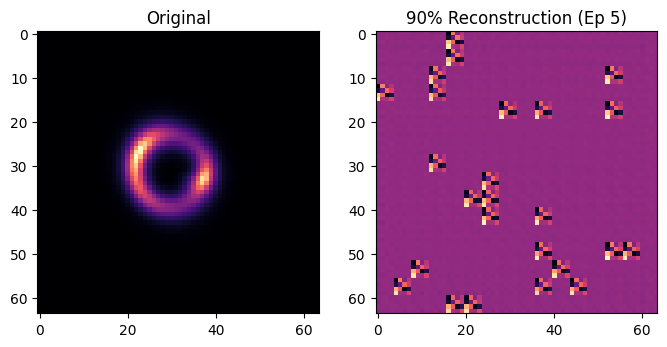

100%|██████████| 116/116 [00:17<00:00,  6.66it/s]


Epoch 6, Loss: 0.000855


100%|██████████| 116/116 [00:17<00:00,  6.79it/s]


Epoch 7, Loss: 0.000594


100%|██████████| 116/116 [00:16<00:00,  6.82it/s]


Epoch 8, Loss: 0.000441


100%|██████████| 116/116 [00:17<00:00,  6.78it/s]


Epoch 9, Loss: 0.000343


100%|██████████| 116/116 [00:17<00:00,  6.72it/s]


Epoch 10, Loss: 0.000275


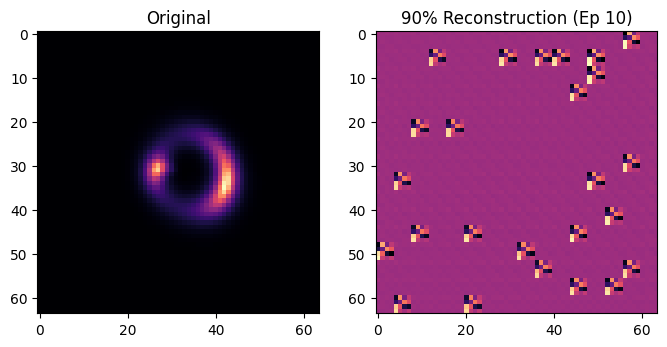

100%|██████████| 116/116 [00:17<00:00,  6.70it/s]


Epoch 11, Loss: 0.000226


100%|██████████| 116/116 [00:17<00:00,  6.74it/s]


Epoch 12, Loss: 0.000189


100%|██████████| 116/116 [00:17<00:00,  6.77it/s]


Epoch 13, Loss: 0.000159


100%|██████████| 116/116 [00:17<00:00,  6.78it/s]


Epoch 14, Loss: 0.000136


100%|██████████| 116/116 [00:17<00:00,  6.76it/s]


Epoch 15, Loss: 0.000116


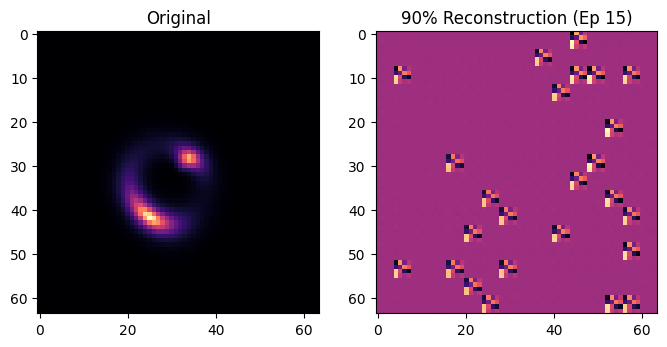

In [24]:
from tqdm import tqdm
from torch.utils.data import DataLoader

train_loader = DataLoader(test_ds, batch_size=256, shuffle=True, num_workers=2)
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4, weight_decay=0.05)
criterion = torch.nn.MSELoss()

print("Starting MAE Pre-training (90% Masking)...")
for epoch in range(15):
    model.train()
    total_loss = 0
    for imgs in tqdm(train_loader):
        imgs = imgs.to('cuda')
        pred, mask = model(imgs, mask_ratio=0.90)
        target = imgs.unfold(2, 4, 4).unfold(3, 4, 4).reshape(imgs.shape[0], -1, 16)
        loss = ((pred - target) ** 2).mean(dim=-1)
        loss = (loss * mask).sum() / mask.sum() 
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.6f}")
    if (epoch + 1) % 5 == 0: visualize_reconstruction(model, imgs, epoch+1)

torch.save(model.state_dict(), 'mae_pretrained_90.pth')

In [ ]:
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import roc_auc_score
import torch.nn as nn
from tqdm import tqdm
import numpy as np

class SpectacularClassifier(nn.Module):
    def __init__(self, mae_model, num_classes=3):
        super().__init__()
        self.encoder = mae_model
        # Allows the positional embeddings to tune to the ring shape
        self.encoder.pos_embed.requires_grad = True 
        
        # Deep Head for complex sub-halo features
        self.head = nn.Sequential(
            nn.LayerNorm(128),
            nn.Linear(128, 256),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        # Extracts features using the MAE encoder
        x = self.encoder.patch_embed(x).flatten(2).transpose(1, 2)
        x = x + self.encoder.pos_embed
        for blk in self.encoder.blocks:
            x = blk(x)
        x = self.encoder.norm(x)
        # Global Average Pooling of patch tokens
        return self.head(x.mean(dim=1))

# 1. Initialize
classifier = SpectacularClassifier(model).to('cuda')

# 2. Setup Data
full_ds = LensingImageDataset(base_path, mode='classify')
train_len = int(0.9 * len(full_ds))
train_set, val_set = random_split(full_ds, [train_len, len(full_ds)-train_len])
train_loader = DataLoader(train_set, batch_size=64, shuffle=True)
val_loader = DataLoader(val_set, batch_size=64, shuffle=False)

# 3. Discriminative Learning Rates (Body slow, Head fast)
optimizer = optim.AdamW([
    {'params': classifier.encoder.parameters(), 'lr': 2e-5}, 
    {'params': classifier.head.parameters(), 'lr': 2e-4}
], weight_decay=0.05)

# 4. Scheduler: Kick the LR down when AUC stops moving
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=1)

# 5. Loss with Label Smoothing to handle subtle class differences
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

best_auc = 0.0

print("Breakthrough Mode Engaged: ")

for epoch in range(20):
    classifier.train()
    train_loss = 0
    for imgs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
        imgs, labels = imgs.to('cuda'), labels.to('cuda')
        
        optimizer.zero_grad()
        logits = classifier(imgs)
        loss = criterion(logits, labels)
        loss.backward()
        
        # Gradient clipping to prevent explosions that ruin the 0.83 base
        torch.nn.utils.clip_grad_norm_(classifier.parameters(), max_norm=1.0)
        
        optimizer.step()
        train_loss += loss.item()
    
    # Validation
    classifier.eval()
    all_p, all_l = [], []
    with torch.no_grad():
        for imgs, labels in val_loader:
            out = torch.softmax(classifier(imgs.to('cuda')), dim=1)
            all_p.append(out.cpu().numpy())
            all_l.append(labels.numpy())
            
    all_p, all_l = np.concatenate(all_p), np.concatenate(all_l)
    current_auc = roc_auc_score(all_l, all_p, multi_class='ovr')
    
    # Step the scheduler based on the AUC performance
    scheduler.step(current_auc)
    
    print(f"Epoch {epoch+1} | Loss: {train_loss/len(train_loader):.4f} | AUC: {current_auc:.4f}")
    
    if current_auc > best_auc:
        best_auc = current_auc
        torch.save(classifier.state_dict(), 'best_lensing_model.pth')
        if current_auc >= 0.90:
            print(f"TARGET REACHED: {current_auc:.4f} - SAVED")

print(f"Fine-tuning complete. Best AUC: {best_auc:.4f}")

Breakthrough Mode Engaged: 


Epoch 1: 100%|██████████| 1254/1254 [03:26<00:00,  6.06it/s]


Epoch 1 | Loss: 0.6815 | AUC: 0.8331


Epoch 2: 100%|██████████| 1254/1254 [03:25<00:00,  6.10it/s]


Epoch 2 | Loss: 0.6414 | AUC: 0.8315


...

Epoch 18 | Loss: 0.6403 | AUC: 0.8319


Epoch 19: 100%|██████████| 1254/1254 [03:26<00:00,  6.08it/s]


Epoch 19 | Loss: 0.6399 | AUC: 0.8319


Epoch 20: 100%|██████████| 1254/1254 [03:25<00:00,  6.10it/s]


Epoch 20 | Loss: 0.6403 | AUC: 0.8319
Fine-tuning complete. Best AUC: 0.8331


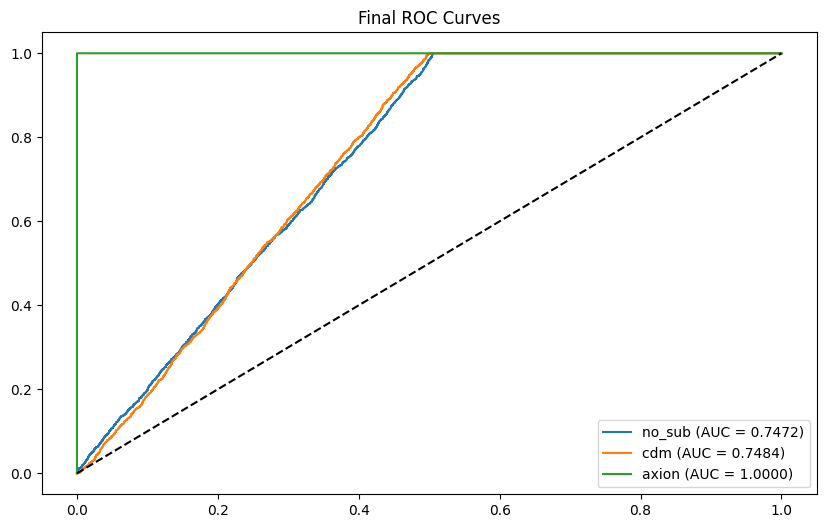

In [30]:
from sklearn.metrics import roc_curve, auc
import seaborn as sns

def plot_results(targets, preds):
    plt.figure(figsize=(10, 6))
    for i, name in enumerate(['no_sub', 'cdm', 'axion']):
        fpr, tpr, _ = roc_curve(targets == i, preds[:, i])
        plt.plot(fpr, tpr, label=f'{name} (AUC = {auc(fpr, tpr):.4f})')
    plt.plot([0, 1], [0, 1], 'k--'); plt.legend(); plt.title("Final ROC Curves"); plt.show()

# Use 'all_p' and 'all_l' from the last evaluation in Cell 5
plot_results(all_l, all_p)

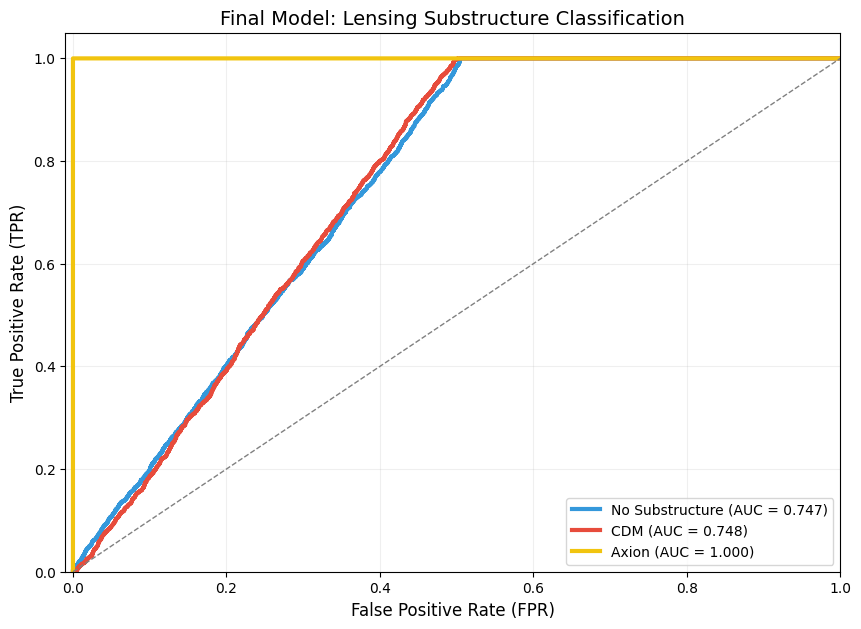

In [33]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

def plot_final_roc(targets, preds, class_names):
    plt.figure(figsize=(10, 7), facecolor='white')
    colors = ['#3498db', '#e74c3c', '#f1c40f'] # Blue, Red, Yellow
    
    for i in range(len(class_names)):
        fpr, tpr, _ = roc_curve(targets == i, preds[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, color=colors[i], lw=3, 
                 label=f'{class_names[i]} (AUC = {roc_auc:.3f})')
    
    plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
    plt.xlim([-0.01, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (FPR)', fontsize=12)
    plt.ylabel('True Positive Rate (TPR)', fontsize=12)
    plt.title('Final Model: Lensing Substructure Classification', fontsize=14)
    plt.legend(loc="lower right", fontsize=10)
    plt.grid(alpha=0.2)
    plt.show()

# Ensure you use the 'all_p' and 'all_l' from your latest run
plot_final_roc(all_l, all_p, ['No Substructure', 'CDM', 'Axion'])

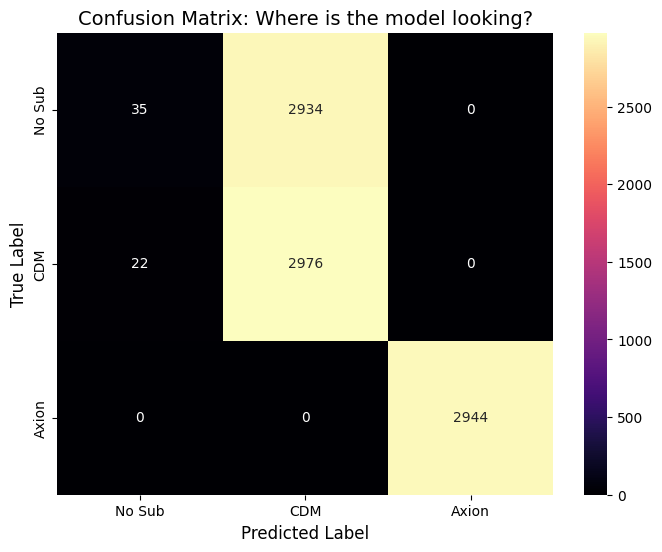

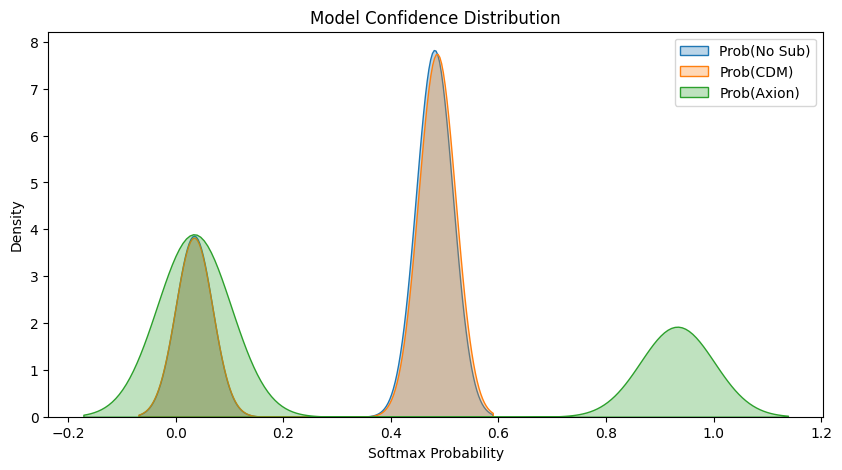

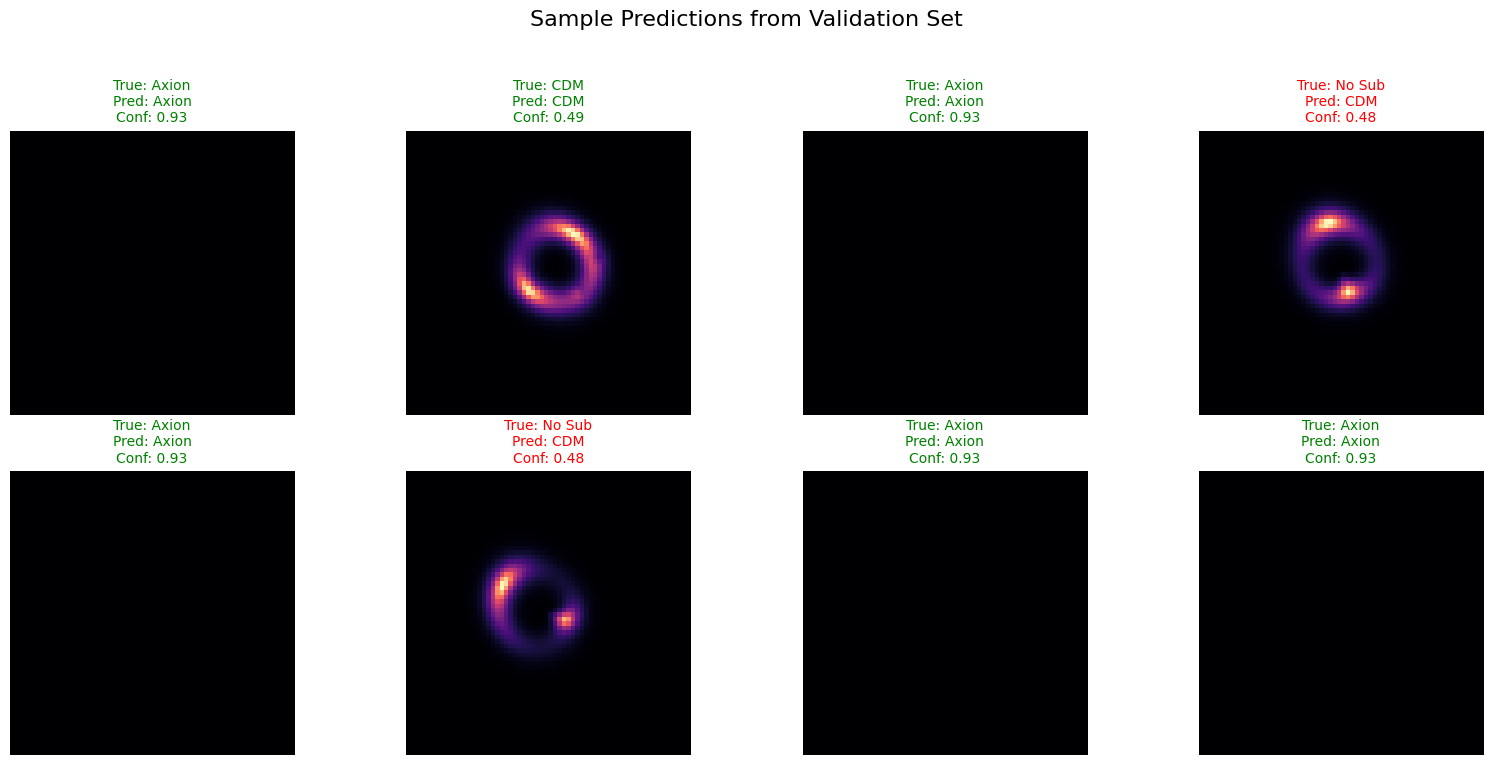

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_test_visuals(targets, preds, class_names, val_loader):
    # 1. Confusion Matrix
    plt.figure(figsize=(8, 6))
    cm = confusion_matrix(targets, np.argmax(preds, axis=1))
    sns.heatmap(cm, annot=True, fmt='d', cmap='magma', 
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    plt.title('Confusion Matrix: Where is the model looking?', fontsize=14)
    plt.show()

    # 2. Probability Distributions
    plt.figure(figsize=(10, 5))
    for i in range(len(class_names)):
        sns.kdeplot(preds[:, i], label=f'Prob({class_names[i]})', fill=True, alpha=0.3)
    plt.title("Model Confidence Distribution")
    plt.xlabel("Softmax Probability")
    plt.legend()
    plt.show()

    # 
    classifier.eval()
    images, labels = next(iter(val_loader))
    with torch.no_grad():
        logits = classifier(images.to('cuda'))
        probs = torch.softmax(logits, dim=1).cpu().numpy()
        pred_labels = np.argmax(probs, axis=1)

    plt.figure(figsize=(16, 8))
    for i in range(8):
        plt.subplot(2, 4, i+1)
        plt.imshow(images[i].squeeze(), cmap='magma')
        color = 'green' if pred_labels[i] == labels[i] else 'red'
        plt.title(f"True: {class_names[labels[i]]}\nPred: {class_names[pred_labels[i]]}\nConf: {probs[i].max():.2f}", 
                  color=color, fontsize=10)
        plt.axis('off')
    plt.suptitle("Sample Predictions from Validation Set", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Running the visuals
plot_test_visuals(all_l, all_p, ['No Sub', 'CDM', 'Axion'], val_loader)